In [69]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: ANYWIDGET_HMR=1


# Gold Drift Series — Show2D Stress Test

Load 12 × 4096×4096 STEM HAADF images from a Velox EMD drift series.
Tests optimized IO (direct h5py, threaded) and Show2D gallery performance.

In [70]:
from quantem.widget import IO, Show2D

## Load all 4K HAADF images (threaded IO)

In [71]:
result = IO.folder("/Users/macbook/data/bob/20260409_gold_drift_v3", file_type="emd", shape=(4096, 4096))

files:   0%|          | 0/14 [00:00<?, ?it/s]

Filtered: kept 12/14 files matching shape=(4096, 4096)
IO.folder: 12×4096×4096 768 MB (12 files) in 571 ms (48 ms/file)  pixel_size=0.1861 Å


## Instrument metadata

In [72]:
result.describe()

  Image:          12 × 4096 × 4096
  Pixel size:     0.1861 Å (0.0186 nm)
  Field of view:  76.2 nm
  Instrument:     Spectra / Titan / XFEG
  Voltage:          300 kV
  Convergence:      30.0 mrad
  Camera length:    91 mm
  Spot size:        6
  Screen current:   0.14 nA
  Dwell time:     2.0 µs  (frame: 38.3 s)
  Scan size:      4096 × 4096
  Detector:       HAADF (63–200 mrad)
  Sample:         gold_3.6mx_drift
  Stage:          x=39.0, y=21.3, z=-199 µm


## Show2D gallery — 12 × 4K HAADF drift series

Show2D: 12×4096×4096 768 MB in 2267 ms


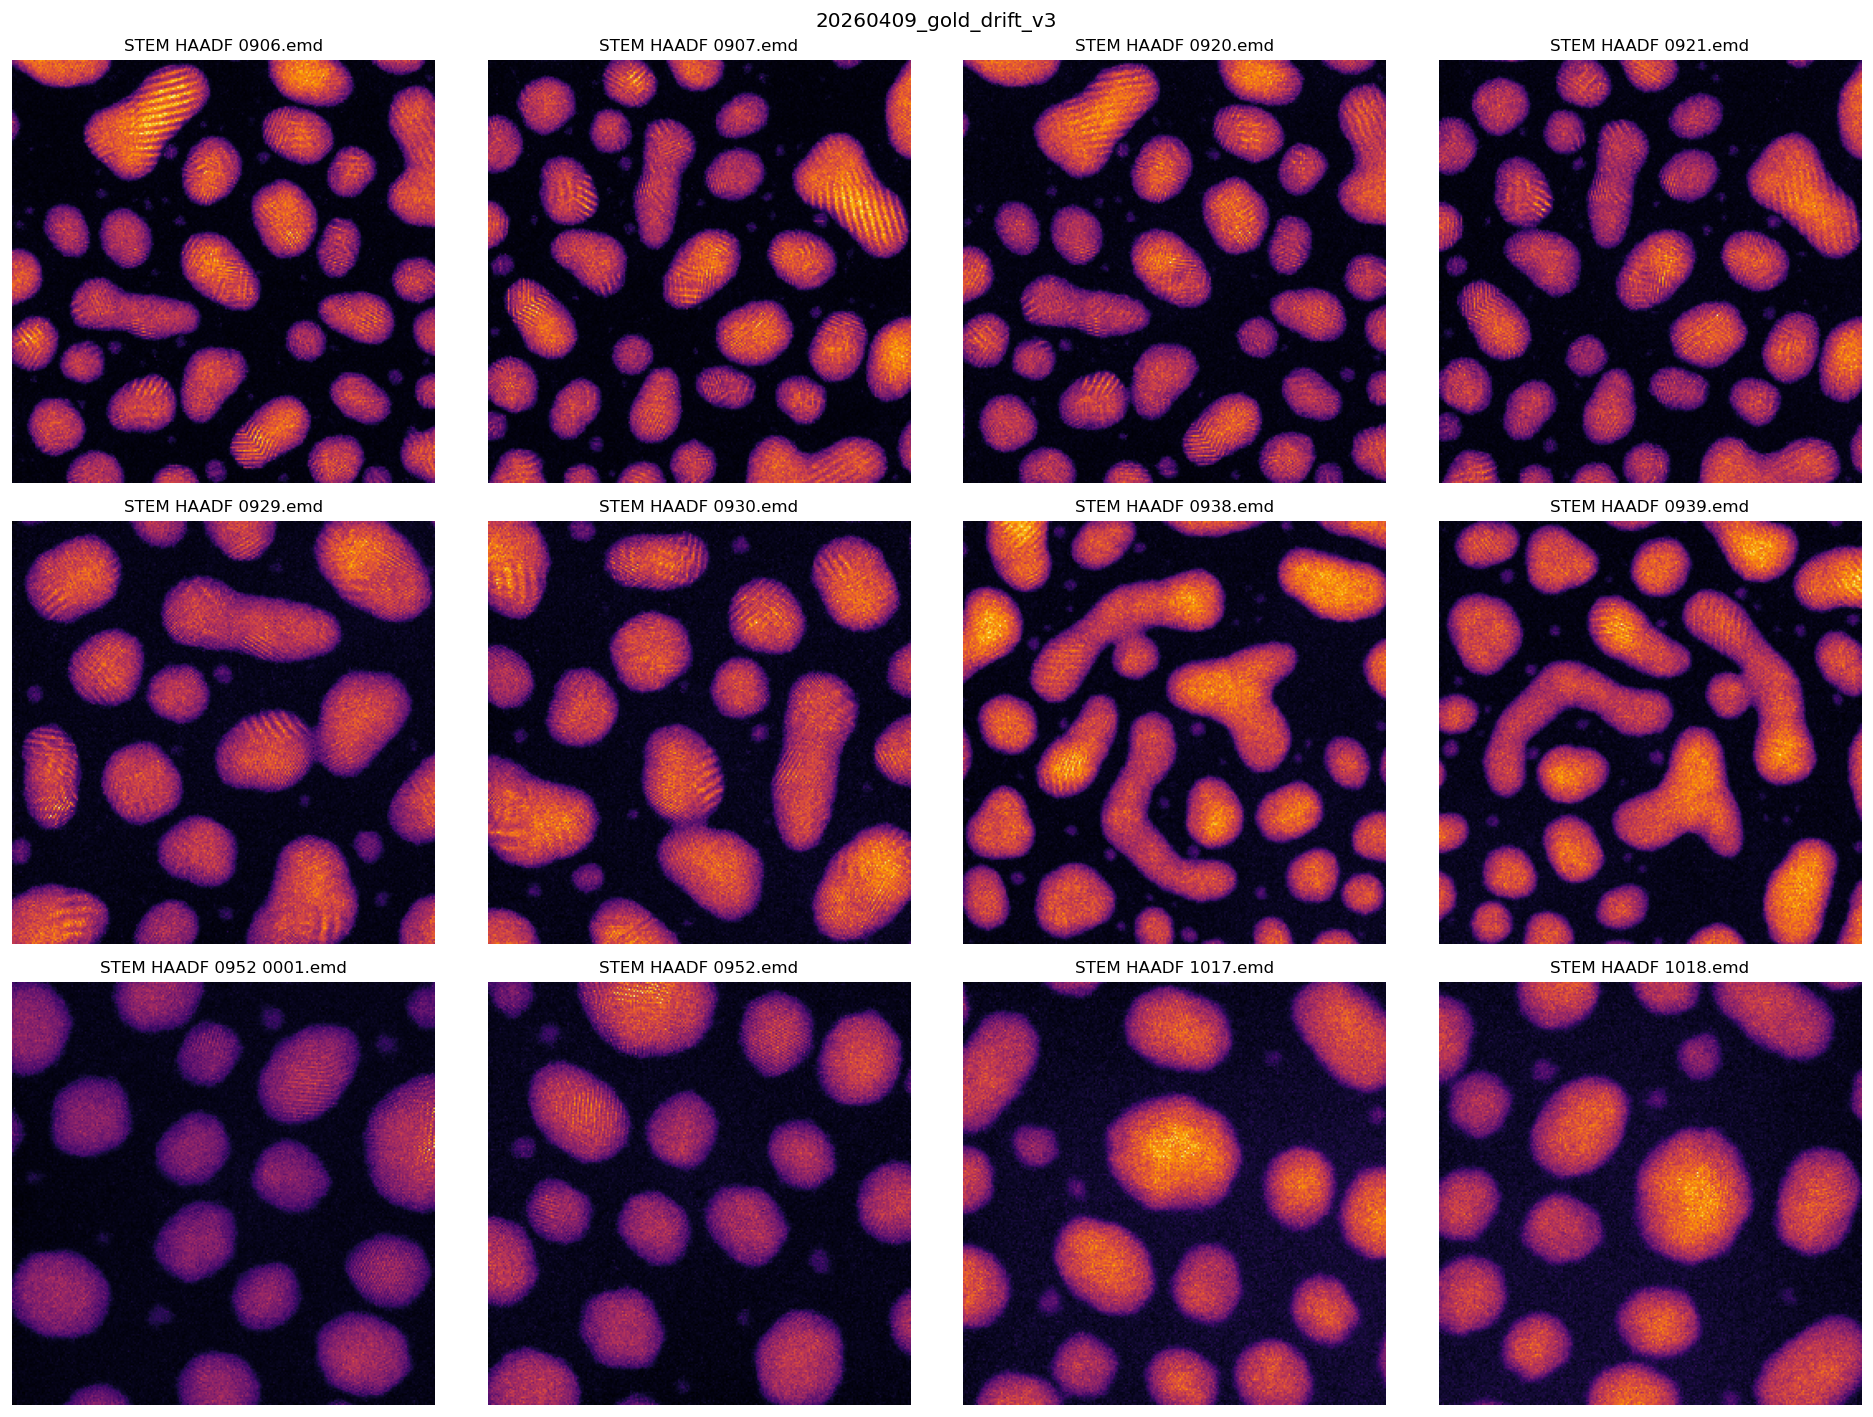

In [73]:
w = Show2D(result, ncols=4)
w

## Query specific metadata

In [74]:
result.describe(keys=["DwellTime", "FrameTime", "AccelerationVoltage", "BeamConvergence"])

  DwellTime: 2.0 µs
  FrameTime: 38.3 s
  AccelerationVoltage: 300 kV
  BeamConvergence: 30.0 mrad


## Single file — full metadata

In [75]:
single = IO.file("/Users/macbook/data/bob/20260409_gold_drift_v3/STEM HAADF 0906.emd")
single.describe()

IO.file: 4096×4096 64 MB in 27 ms  pixel_size=0.1861 Å
  Image:          4096 × 4096
  Pixel size:     0.1861 Å (0.0186 nm)
  Field of view:  76.2 nm
  Instrument:     Spectra / Titan / XFEG
  Voltage:          300 kV
  Convergence:      30.0 mrad
  Camera length:    91 mm
  Spot size:        6
  Screen current:   0.14 nA
  Dwell time:     2.0 µs  (frame: 38.3 s)
  Scan size:      4096 × 4096
  Detector:       HAADF (63–200 mrad)
  Sample:         gold_3.6mx_drift
  Stage:          x=39.0, y=21.3, z=-199 µm


## GPU Colormap Diagnostic

Run this cell, open browser console (Cmd+Option+J), then check for `[GPU-DIAG]` messages. Copy and paste the console output to debug the GPU colormap.

In [76]:
w.cmap = 'hot'